<a href="https://colab.research.google.com/github/itsparmeet007/ML-Projects/blob/main/Exersize10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

In [ ]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns',inplace=True)

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1_jF6vmRyspDjHZ3nQ-y2DdFcow0rFNs7tYqg34wvyJ0/edit#gid=0


In [ ]:
df.shape

(891, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   Fare      891 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 34.9+ KB


In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
Fare,0


In [ ]:
df['Age'] = df.groupby(['Sex','Pclass'])['Age']\
            .transform(lambda x:x.fillna(x.median()))

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


In [ ]:
inputs = df.drop("Survived",axis = 1)
target = df['Survived']

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
inputs['Sex'] = le.fit_transform(df['Sex'])

In [ ]:
inputs.head()

,Pclass,Sex,Age,Fare
0,3,1,22.0,7.2500
1,1,0,38.0,71.2833
2,3,0,26.0,7.9250
3,1,0,35.0,53.1000
4,3,1,35.0,8.0500


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test,y_train,y_test = train_test_split(inputs,target,test_size = 0.2 , random_state= 42)


In [ ]:
print(len(X_train))
print(len(X_test))

712
179


In [ ]:
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,precision_score,recall_score

y_pred = model.predict(X_test)
print(accuracy_score(y_test,y_pred)*100)
print(f1_score(y_test,y_pred)*100)
print(precision_score(y_test,y_pred)*100)
print(recall_score(y_test,y_pred)*100)


77.6536312849162
73.68421052631578
71.7948717948718
75.67567567567568


In [ ]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
cm

array([[83, 22],
       [18, 56]])

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

print(model.predict([[1,0,30,70]]))
print(model.predict([[2,1,30,45]]))
print(model.predict([[3,1,30,7]]))

[1]
[0]
[0]


Text(95.72222222222221, 0.5, 'Actual')

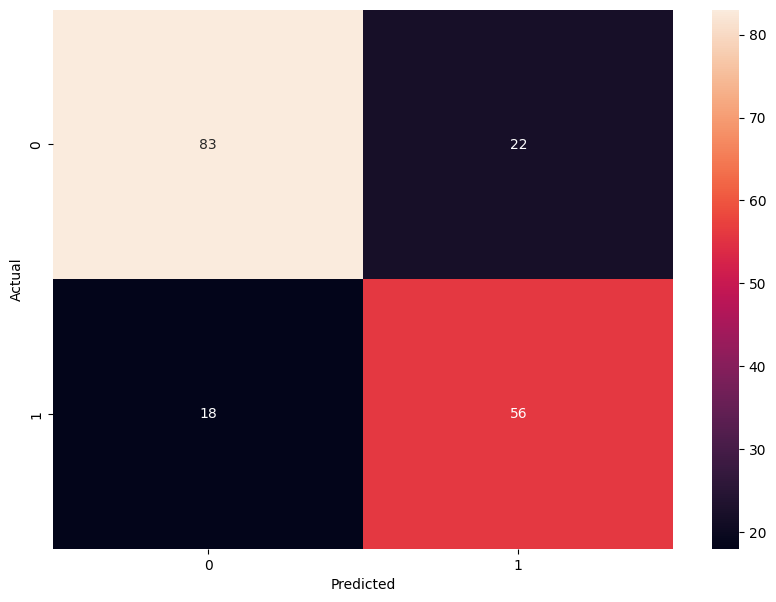

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')


**83 passengers correctly predicted as not survived**

**56 passengers correctly predicted as survived**

**22 false alarms (predicted survived but didn’t)**

**18 missed survivors (model failed to detect)**

**“A Decision Tree Classifier was trained on the Titanic dataset using key features such as Sex, Age, Pclass, and Fare. The model achieved an accuracy of 77.65% with balanced precision and recall, and the confusion matrix visualization confirmed reliable classification performance.”**